# Comparing methods of hurricane forecast uncertainty
##### author: Elizabeth A. Barnes, Randal J. Barnes and Mark DeMaria

In [1]:
import sys
sys.path.append('..')

import datetime
import imp
import os
import pickle
import pprint
import random
import time

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

import tensorflow_probability as tfp
from sklearn import preprocessing
from silence_tensorflow import silence_tensorflow

from build_data import build_hurricane_data
import build_model
import experiment_settings
from save_model_run import save_model_run
from training_instrumentation import TrainingInstrumentation

C:\Users\barne\AppData\Local\Temp\ipykernel_8124\36319899.py:5: DeprecationWarning: the imp module is deprecated in favour of importlib; see the module's documentation for alternative uses
  import imp


In [2]:
__author__ = "Randal J Barnes and Elizabeth A. Barnes"
__version__ = "05 August 2022"

silence_tensorflow()
tf.config.set_visible_devices([], 'GPU') # turn-off tensorflow-metal if it is on

imp.reload(experiment_settings)

EXP_NAME = "bivariate_normal_101_EPCP48"
TESTING_YEARS_LIST = (2020,)

OVERWRITE_MODEL = False
DATA_PATH = "../data/"
MODEL_PATH = "saved_models/"

settings = experiment_settings.get_settings(EXP_NAME)
settings["years_test"] = (2020,)
settings['rng_seed'] = 123

In [3]:
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["figure.dpi"] = 150
np.warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

## Start looping through runs

In [4]:
# set random seeds
np.random.seed(settings['rng_seed'] )
random.seed(settings['rng_seed'] )                            
tf.random.set_seed(settings['rng_seed'] ) 

network_seed = settings['rng_seed']

# Create the model name.
model_name = "BETA_TESTING" + "_" + EXP_NAME
pprint.pprint(model_name)

'BETA_TESTING_bivariate_normal_101_EPCP48'


In [5]:
imp.reload(build_model)

# Build the track data tensors for a bivariate normal model.
(
    data_summary,        
    x_train,
    onehot_train,
    x_val,
    onehot_val,
    x_test,
    onehot_test,        
    x_valtest,
    onehot_valtest,
    df_train,
    df_val,
    df_test,
    df_valtest,
) = build_hurricane_data(DATA_PATH, settings, verbose=2)

years(2020,) withheld for testing
{'datafile_path': '../data/nnfit_vlist_02-Jun-2022.dat',
 'onehot_test_shape': (123, 5),
 'onehot_train_shape': (1860, 5),
 'onehot_val_shape': (200, 5),
 'onehot_valtest_shape': (323, 5),
 'x_names': ['NCT',
             'VMAX0',
             'AVDX',
             'EMDX',
             'EGDX',
             'HWDX',
             'AVDY',
             'EMDY',
             'EGDY',
             'HWDY',
             'LONC',
             'LATC',
             'VMXC',
             'DV12',
             'SLAT',
             'SHDC',
             'SSTN',
             'DTL',
             'DSDV',
             'LGDV',
             'HWDV',
             'AVDV'],
 'x_test_shape': (123, 22),
 'x_train_shape': (1860, 22),
 'x_val_shape': (200, 22),
 'x_valtest_shape': (323, 22),
 'y_names': ['OBDX', 'OBDY']}


                        |   cnt |    min |   25% |   50% |   75% |   max |   avg |   std |   iqr
------------------------+-------+--------+-------+-------+-------+----

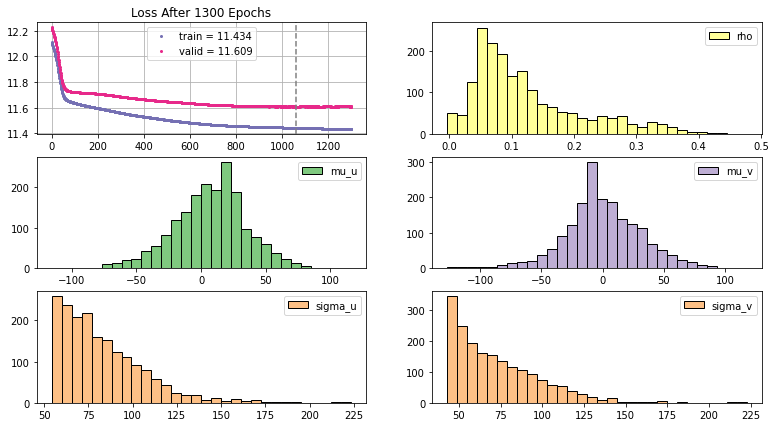

Restoring model weights from the end of the best epoch: 1062.
Epoch 01312: early stopping


In [6]:
# Define the callbacks
earlystoping_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=settings["patience"],
    restore_best_weights=True,
    verbose=1,
)

training_callback = TrainingInstrumentation(
    x_train,
    onehot_train,
    interval=50,
)

callbacks = [earlystoping_callback, 
             training_callback,
            ]

# Make, compile, and train the model
tf.keras.backend.clear_session()            
model = build_model.make_model(
    settings,
    x_train,
    onehot_train,
    model_compile=True,
)   
model.summary()

# check if the model exists
model_savename = MODEL_PATH + model_name + "_weights.h5"
if os.path.exists(model_savename) and OVERWRITE_MODEL==False:
    print(model_savename + 'exists. Skipping...')

# train the network
start_time = time.time()
history = model.fit(
    x_train,
    onehot_train,
    validation_data=(x_val, onehot_val),
    batch_size=settings["batch_size"],
    epochs=settings["n_epochs"],
    shuffle=True,
    verbose=0,
    callbacks=callbacks,
)
stop_time = time.time()


In [7]:
# Display the results, and save the model rum.
best_epoch = np.argmin(history.history["val_loss"])
fit_summary = {
    "network_seed": network_seed,
    "elapsed_time": stop_time - start_time,
    "best_epoch": best_epoch,
    "loss_train": history.history["loss"][best_epoch],
    "loss_valid": history.history["val_loss"][best_epoch],
}
pprint.pprint(fit_summary, width=80)

save_model_run(
    data_summary,
    fit_summary,
    model,
    MODEL_PATH,
    model_name,
    settings,
    __version__,
)

{'best_epoch': 1061,
 'elapsed_time': 78.65951013565063,
 'loss_train': 11.443801879882812,
 'loss_valid': 11.607168197631836,
 'network_seed': 123}
